# Offset Calculation

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[3.eeg_blink_signals.ipynb](./3.eeg_blink_signals.ipynb)|<i>4.offset_calculation.ipynb</i>|[5.frame_alignment.ipynb](./5.frame_alignment.ipynb)|

 This notebook is geared towards aligning the blinks detected by the "Mind Monitor" application, the EEG signal corresponding to that blink, and the blink estimated based on eye-tracking.

 In [2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb), we generated a `src/data2/vr_blinks.csv` file that tracks the blinks detected from the VR eye-tracking data. Furthermore, in [3.eeg_blink_signals.ipynb](./3.eeg_blink_signals.ipynb), we generated `src/data2/tp9_blinks.csv` and `src/data2/tp10_blinks.csv`, which tracks blinks detected in the EEG data.

The idea is that we want to estiamte if there's a consistent way to detect the blinks based on the hardware, and then adjust the data to **align** them better. This thus removes any inconsistencies regarding timing, hopefully. The best way to do that is to analyze the three files above.

## Step 0: Imports

In [13]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown
import importlib

from components import file_handling
importlib.reload(file_handling)

_DATA_DIR = os.path.join('.', 'data2')
_ACTIVE_PARTICIPANTS = [
    'P1',
    'PI2',
    'P3',
    'P4_Muse2',
    'P5',
    'P6',
    'P7',
    'P9'
]

## Step 1: Read the 3 Files

We need to read `src/data2/vr_blinks.csv`, `src/data2/tp9_blinks.csv`, and `src/data2/tp10_blinks.csv`.

In [14]:
def read_files(dir:str, p:str):
    vr = pd.read_csv(os.path.join(dir, p, 'vr_blinks.csv'))
    tp9 = pd.read_csv(os.path.join(dir, p, 'tp9_blinks.csv'))
    tp10 = pd.read_csv(os.path.join(dir, p, 'tp10_blinks.csv'))
    return {'p':p, 'vr':vr, 'tp9':tp9, 'tp10':tp10}

participant_files = [read_files(_DATA_DIR, p) for p in _ACTIVE_PARTICIPANTS]
for p in participant_files:
    display(Markdown(f"### Participant {p['p']}"))
    display(Markdown("#### VR Blinks:"))
    display(p['vr'].head(4))
    display(Markdown("#### TP9 Blinks:"))
    display(p['tp9'].head(4))
    display(Markdown("#### TP10 Blinks:"))
    display(p['tp10'].head(4))

### Participant P1

#### VR Blinks:

,trial_id,overlap_counter,type,x,y
0,1,1,peak,1758744740066,1.310940
1,1,2,valley,1758744741305,-1.259361
2,1,3,valley,1758744742678,-2.538284
3,1,4,valley,1758744743844,-3.536386


#### TP9 Blinks:

,trial_id,overlap_counter,type,x,y
0,1,1,valley,1758744740139,-2.294485
1,1,2,valley,1758744741439,-2.355844
2,1,3,valley,1758744742562,-2.354613
3,1,4,valley,1758744743783,-2.279018


...

,trial_id,overlap_counter,type,x,y
0,1,2,valley,1763826063546,-2.006902
1,1,3,peak,1763826064698,0.916586
2,1,4,peak,1763826065960,2.255101
3,2,2,peak,1763826087763,2.367089


#### TP9 Blinks:

,trial_id,overlap_counter,type,x,y
0,1,2,valley,1763826063510,-2.238880
1,1,3,valley,1763826064643,-1.986386
2,1,4,valley,1763826065859,-1.884637
3,2,2,valley,1763826087735,-2.373918


#### TP10 Blinks:

,trial_id,overlap_counter,type,x,y
0,1,2,valley,1763826063510,-2.293298
1,1,3,valley,1763826064643,-1.966182
2,1,4,valley,1763826065859,-1.886318
3,2,2,valley,1763826087735,-2.469764


## Step 2: Inner Merge Datasets + Calculate Offsets

Let's do an inner merge between the VR data and each of the EEG channels. The offsets is calculated from subtracting the EEG timestamps with the VR timestamps. If the EEG blinks occur later than the VR data, then the offset should be _positive_. However, if the EEG blinks occur before the VR data, then the offset should be _negative_.

In [15]:
def merge_datasets(vr,eeg):
    merged = pd.merge(
        left = vr[['trial_id', 'overlap_counter', 'x']],
        right = eeg[['trial_id', 'overlap_counter', 'x']],
        on=['trial_id', 'overlap_counter'],
        how='inner'
    )
    merged.rename(columns={'x_x':'vr_x', 'x_y':'eeg_x'}, inplace=True)
    merged['offset'] = merged['eeg_x'] - merged['vr_x']
    return merged

participant_blinks = []
for p in participant_files:
    # Merge the VR data and TP9 data
    vr_tp9 = merge_datasets(p['vr'], p['tp9'])
    vr_tp10 = merge_datasets(p['vr'], p['tp10'])

    display(Markdown(f"### Participant {p['p']}"))
    display(Markdown("#### VR vs TP9"))
    display(vr_tp9.head(4))
    display(Markdown("#### VR vs TP10"))
    display(vr_tp10.head(4))

    participant_blinks.append({**p, 'vr_tp9':vr_tp9, 'vr_tp10':vr_tp10})

### Participant P1

#### VR vs TP9

,trial_id,overlap_counter,vr_x,eeg_x,offset
0,1,1,1758744740066,1758744740139,73
1,1,2,1758744741305,1758744741439,134
2,1,3,1758744742678,1758744742562,-116
3,1,4,1758744743844,1758744743783,-61


#### VR vs TP10

,trial_id,overlap_counter,vr_x,eeg_x,offset
0,1,1,1758744740066,1758744740139,73
1,1,2,1758744741305,1758744741439,134
2,1,3,1758744742678,1758744742562,-116
3,1,4,1758744743844,1758744743783,-61


...

### Participant P9

#### VR vs TP9

,trial_id,overlap_counter,vr_x,eeg_x,offset
0,1,2,1763826063546,1763826063510,-36
1,1,3,1763826064698,1763826064643,-55
2,1,4,1763826065960,1763826065859,-101
3,2,2,1763826087763,1763826087735,-28


#### VR vs TP10

,trial_id,overlap_counter,vr_x,eeg_x,offset
0,1,2,1763826063546,1763826063510,-36
1,1,3,1763826064698,1763826064643,-55
2,1,4,1763826065960,1763826065859,-101
3,2,2,1763826087763,1763826087735,-28


## Step 3: Visualize the Offsets

We'll generate boxplots for each participant. The boxplots represent the timing offsets between the eeg timestamps and the vr timestamps. To do this, we need to combine the dataframes into a singular long dataframe.

### 3a. Merge Dataframes into a Global DataFrame

In [16]:
data_list = []
for i, p in enumerate(participant_blinks, start=1):
    # copy to prevent mutation
    vr_tp9 = p['vr_tp9'].copy()
    vr_tp10 = p['vr_tp10'].copy()

    # Append new data
    vr_tp9["participant"] = p['p']
    vr_tp10["participant"] = p['p']
    
    # Create a new channel to distinguish between the two of them.
    vr_tp9["eeg_channel"] = "tp9"
    vr_tp10["eeg_channel"] = "tp10"

    # Let's also create a `combined` version
    combined = pd.concat([vr_tp9, vr_tp10], ignore_index=True)
    combined["eeg_channel"] = "combined"
    combined["participant"] = p['p']

    data_list.append(vr_tp9[["participant", "eeg_channel", "offset"]])
    data_list.append(vr_tp10[["participant", "eeg_channel", "offset"]])
    data_list.append(combined[["participant", "eeg_channel", "offset"]])

dfs = pd.concat(data_list, ignore_index=True)
display(dfs)

,participant,eeg_channel,offset
0,P1,tp9,73
1,P1,tp9,134
2,P1,tp9,-116
3,P1,tp9,-61
4,P1,tp9,-71
...,...,...,...
603,P9,combined,11
604,P9,combined,17
605,P9,combined,-154
606,P9,combined,-25


### 3b. Boxplots (TP9 vs TP10 vs Combined)

Let's generate a singular figure that analyzes the differences between participants and EEG channel. We'll save this plot inside of `src/docs/4.alignment/offsets.png`

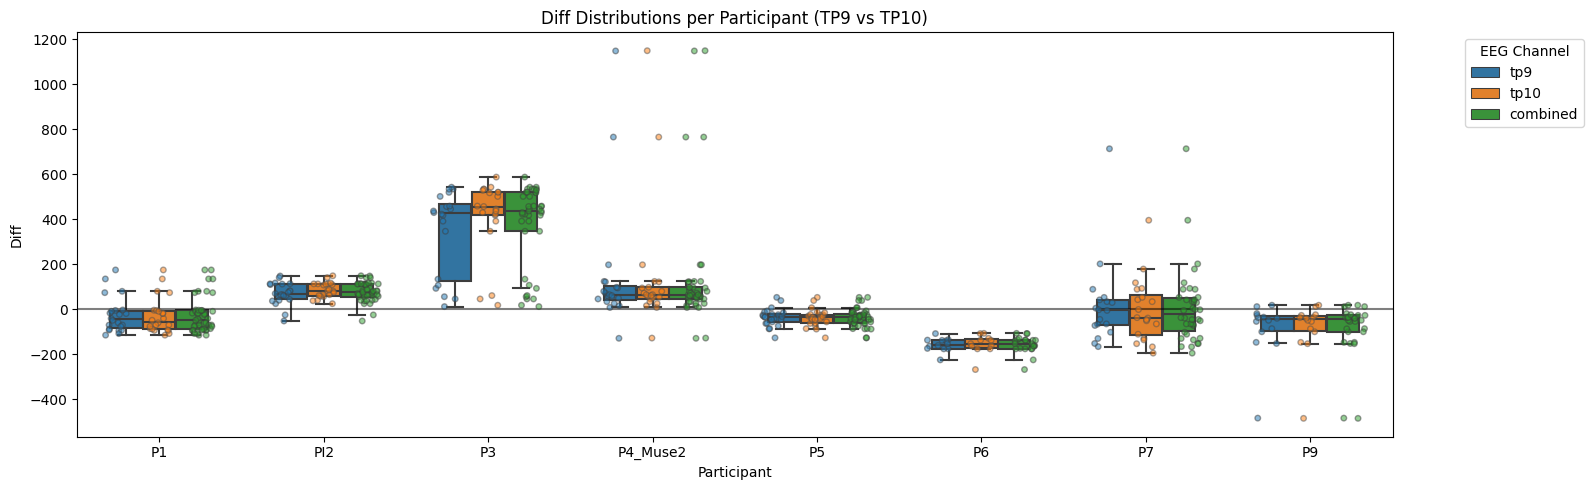

In [17]:
# Generate the plot
plt.figure(figsize=(len(participant_blinks) * 2, 5))  # scale height with N

# Plot the boxplots
sns.boxplot(
    data=dfs,
    x="participant",   # horizontal orientation: y is category, x is value
    y="offset",
    hue="eeg_channel",
    orient="v",
    showfliers=False,  # hide outlier dots (since we'll show raw data)
    width=0.6,
)

# Overlay jittered raw points
sns.stripplot(
    data=dfs,
    x="participant",
    y="offset",
    hue="eeg_channel",
    dodge=True,
    orient="v",
    alpha=0.5,
    jitter=0.2,
    linewidth=1,
    edgecolor='gray',
    size=4,
)

plt.title("Diff Distributions per Participant (TP9 vs TP10)")
plt.xlabel("Participant")
plt.ylabel("Diff")

# Add lines to indicate the 0-diff line
plt.axhline(y=0, c='black', alpha=0.5)

# Avoid duplicate legends from boxplot + stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], title="EEG Channel", bbox_to_anchor=(1.05, 1), loc="upper left")

# Adjust the layout
plt.tight_layout()

# Save the figure
fig_output_dir = os.path.join('.','docs','4.alignment')
file_handling.mkdirs(fig_output_dir)
plt.savefig(os.path.join(fig_output_dir, 'offsets.png'), bbox_inches='tight', dpi=300)

# Show the plot
plt.show()

### 3c. Analysis of Boxplots

With the exception of some outliers, the data is, surprisingly, very consistent. The worst case is P3, which in of itself can be considered an outlier due to noisy eye data. But across the other 5 people (P1, PI2, P2, P4_Muse2, and P5), the data is pretty tightly confined. In other words, there's some consistency between the data.

There's something interesting going on as well. For P1, P2, and P5, the difference between the EEG data and the VR blink data is **in the negative**. This means that the EEG data actually comes BEFORE the VR dta. Furthermore, in PI2 and P4_Muse2, the EEG dta comes, expectedly, after the VR data. This means that there is **variation between participants**.

## Step 4: Extract Common Offsets Per Participant

Now that we are pretty certain that the median is a pretty stable metric, let's create an output dataframe that maps, per each participant, their mean offset. We give the choice of wether to do this per EEG channel or combined.|

In [18]:
# Group the dfs to calculate the median of `offset` based on `participant` and `eeg_channel`. Also do some renaming.
offset_medians = dfs.groupby(['participant', 'eeg_channel'], as_index=False)['offset'].median()
offset_medians.rename(columns={'offset':'offset_median'}, inplace=True)

# Re-sort the rows in accordance to `_ACTIVE_PARTICIPANTS`
offset_medians["participant"] = pd.Categorical(
    offset_medians["participant"],
    categories=_ACTIVE_PARTICIPANTS,
    ordered=True
)
offsets_df = offset_medians.sort_values("participant")
display(offsets_df)

# Save the offsets 
offsets_df.to_csv(os.path.join('.', 'data2', 'blink_offsets.csv'), index=False)

,participant,eeg_channel,offset_median
0,P1,combined,-50.0
1,P1,tp10,-55.5
2,P1,tp9,-46.0
21,PI2,combined,77.0
22,PI2,tp10,81.0
23,PI2,tp9,69.0
3,P3,combined,436.0
5,P3,tp9,425.5
4,P3,tp10,456.0
6,P4_Muse2,combined,64.0


## What's Next?

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[3.eeg_blink_signals.ipynb](./3.eeg_blink_signals.ipynb)|<i>4.offset_calculation.ipynb</i>|[5.frame_alignment.ipynb](./5.frame_alignment.ipynb)|

The next step is to estimate the EEG data in relation to not Unix MS, but rather the frames of the VR data. This is purely to help identify events that happen in the VR simulation with the EEG data, for visualization's sake. We do this in [5.frame_alignment.ipynb](./5.frame_alignment.ipynb).